# Projet 4 — Prévision des précipitations (RainTomorrow)


**Année universitaire : 2025–2026**  
**Encadrant : Pr. Soumia Ziti**  
**Étudiants : HENOVI Komla Alban ; DIOP Asta Walo**


Notebook structuré au format **IMRADC** (Introduction / Méthodes / Résultats / Discussion / Conclusion) et aligné sur la démarche demandée.


- Dataset : `../data/weatherAUS.csv` (Rain in Australia)


- Cible : `RainTomorrow` (Yes/No)


- Critère prioritaire : **Recall** (ne pas manquer les jours de pluie), puis **F1** et **AUC**


---


## IMRADC — Introduction (Contexte scientifique)


La prévision immédiate (nowcasting) et à court terme des précipitations est critique pour :


- l’agriculture (planification, irrigation)


- la gestion du risque d’inondation


Les variables prédictives de la pluie incluent des variables **thermodynamiques** et **dynamiques** :


- humidité (ex: `Humidity3pm`)


- pression (ex: `Pressure3pm`)


- température (`MinTemp`, `MaxTemp`, `Temp3pm`)


- variables de vent (`WindGustSpeed`, directions)


### Équivalent Orange


- Documentation/texte : utilise des **Text** widgets (ou annotations sur le workflow)


- Tu peux aussi ajouter un **Python Script** widget pour générer des figures/analyses identiques au notebook si un widget manque.


## IMRADC — Méthodes



Dans les sections suivantes, on suit exactement la démarche imposée :

1) Contexte & variables

2) Exploration

3) Nettoyage (colonnes trop vides + encodage directions du vent)

4) Relations bivariées (boxplots humidité/pression vs classe)

5) Standardisation

6) ACP

7) Baseline (Logistic Regression)

8) Arbres (Random Forest + Gradient Boosting/XGBoost)

9) Optimisation (profondeur)

10) Évaluation (Recall, F1)

11) Interprétation (variables déterminantes)

Bonus: calibration + réseau de neurones



### Équivalent Orange

- Structure le workflow en “blocs” et annote-les : **File → Select Columns → Preprocess → PCA → Learners → Test & Score → Confusion Matrix/ROC/Calibration**

- Si une étape manque, passe par **Python Script**.


In [17]:
# Étape 1 — Imports & configuration
# On centralise ici tous les imports pour éviter les surprises plus tard.

import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)
from sklearn.calibration import CalibrationDisplay

RANDOM_STATE = 42
DATA_PATH = Path('..') / 'data' / 'weatherAUS.csv'
DATA_PATH


WindowsPath('../data/weatherAUS.csv')

## 2) Chargement des données

On charge le fichier CSV et on vérifie rapidement :

- la forme du dataset (lignes, colonnes)

- un aperçu des premières lignes

### Équivalent Orange

- **File** : charger `weatherAUS.csv`

- **Data Table** : afficher un aperçu des lignes/colonnes

- (Optionnel) **Select Columns** : vérifier que `RainTomorrow` est bien la cible (discrète Yes/No)

In [18]:
# Étape 2 — Lecture du CSV
# Objectif: charger les données *brutes* sans les modifier.
# Pourquoi: on veut d'abord observer la structure (colonnes, valeurs manquantes, types).

df = pd.read_csv(DATA_PATH)
print('Shape:', df.shape)

# Aperçu des premières lignes pour vérifier visuellement les colonnes.
display(df.head())


Shape: (145460, 23)


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


## 2) Exploration (variables clés)



On explore les distributions et valeurs extrêmes des variables demandées :

- `MinTemp`, `MaxTemp`

- `Rainfall`

- `Evaporation`

- `Sunshine`



Objectif: repérer l’échelle des variables, les outliers, et la quantité de NaN.



### Équivalent Orange

- **Distributions** (histogrammes)

- **Box Plot** (détecter outliers)

- Si besoin: **Python Script** pour des plots personnalisés.


In [ ]:
# Exploration demandée: distributions simples
cols = ["MinTemp", "MaxTemp", "Rainfall", "Evaporation", "Sunshine"]
cols = [c for c in cols if c in df.columns]

display(df[cols].describe(include="all").T)

# Histogrammes
n = len(cols)
fig, axes = plt.subplots(1, n, figsize=(4*n, 3), constrained_layout=True)
if n == 1:
    axes = [axes]
for ax, c in zip(axes, cols):
    sns.histplot(df[c], bins=40, kde=False, ax=ax)
    ax.set_title(c)
plt.show()

# Boxplots (outliers)
fig, axes = plt.subplots(1, n, figsize=(4*n, 3), constrained_layout=True)
if n == 1:
    axes = [axes]
for ax, c in zip(axes, cols):
    sns.boxplot(y=df[c], ax=ax)
    ax.set_title(c)
plt.show()


## 3) Inspection rapide & qualité des données

But : comprendre la structure et les problèmes classiques du dataset.

- Types de colonnes (numériques vs catégorielles)

- % de valeurs manquantes (NaN)

- Distribution de la cible `RainTomorrow` (déséquilibre de classes)

### Équivalent Orange

- **Feature Statistics** : types, min/max, valeurs manquantes

- **Distributions** : distribution de la cible et des variables

- **Select Columns** : repérer rapidement les colonnes à retirer (ex: trop de NaN)

In [ ]:
# Étape 3 — Qualité des données
# On répond ici à 3 questions simples:
# 1) Quelles colonnes sont numériques / catégorielles ?
# 2) Quelles colonnes ont beaucoup de valeurs manquantes ?
# 3) La cible RainTomorrow est-elle déséquilibrée (beaucoup plus de "No" que de "Yes") ?

display(df.info())

# Pourcentage de valeurs manquantes par colonne
missing = (df.isna().mean() * 100).sort_values(ascending=False)
display(missing.head(15).to_frame('missing_%'))

target_col = 'RainTomorrow'
print('Target value counts (raw):')
display(df[target_col].value_counts(dropna=False))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

None

,missing_%
Sunshine,48.009762
Evaporation,43.166506
Cloud3pm,40.807095
Cloud9am,38.421559
Pressure9am,10.356799
Pressure3pm,10.331363
WindDir9am,7.263853
WindGustDir,7.098859
WindGustSpeed,7.055548
Humidity3pm,3.098446


Target value counts (raw):


RainTomorrow
No     110316
Yes     31877
NaN      3267
Name: count, dtype: int64

## 4) Nettoyage minimal & définition X/y

Hypothèses simples (prototype) :

- On supprime les lignes où la cible est manquante (sinon impossible d’apprendre)

- On encode la cible : `Yes -> 1`, `No -> 0`

- On retire `Date` pour éviter une mauvaise gestion de la temporalité dans un premier jet

  (une version plus avancée peut encoder la date ou faire un split temporel)

### Équivalent Orange

- **Select Columns** : définir `RainTomorrow` comme Target et retirer `Date` (dans ce prototype)

- Orange gère directement une cible discrète (Yes/No) : pas besoin de la convertir en 0/1 dans Orange

- **Select Rows** (ou filtrage) : retirer les lignes où `RainTomorrow` est manquant, si nécessaire

In [19]:
# Étape 4 — Définir X (features) et y (cible)
# - On supprime les lignes où la cible est manquante (impossible d'entraîner sans label).
# - On encode la cible Yes/No -> 1/0 (format attendu par la plupart des modèles sklearn).
# - On retire Date pour ce prototype (sinon il faut un encodage temporel propre).

target_col = 'RainTomorrow'

# 1) Retirer les lignes sans cible
df = df.dropna(subset=[target_col]).copy()

# 2) Encodage binaire de la cible
# Yes = 1 (pluie demain), No = 0 (pas de pluie demain)
y = df[target_col].map({'Yes': 1, 'No': 0}).astype(int)

# 3) Construire X (toutes les colonnes sauf la cible, et Date si elle existe)
cols_to_drop = [target_col]
if 'Date' in df.columns:
    cols_to_drop.append('Date')

X = df.drop(columns=cols_to_drop)

print('X shape:', X.shape)
print('y mean (rain rate):', y.mean().round(4))
display(y.value_counts().rename({0: 'No', 1: 'Yes'}))


X shape: (142193, 21)
y mean (rain rate): 0.2242


RainTomorrow
No     110316
Yes     31877
Name: count, dtype: int64

## 3) Nettoyage (colonnes trop vides + encodage vent)



Nettoyage demandé :

- **Suppression des variables trop vides** (beaucoup de NaN)

- **Encodage des directions du vent**



Choix prototype (transparent et simple) :

- On supprime les colonnes dont le % de NaN dépasse un seuil (ex: 40%)

- Directions du vent : encodage **cyclique** via angle → `sin`/`cos` (plus “physique” qu’un one-hot)



### Équivalent Orange

- Colonnes trop vides : **Select Columns** (retirer), ou **Impute** si tu choisis de garder

- Directions du vent :

  - soit **Continuize/One-hot** (simple)

  - soit **Python Script** pour encoder en `sin/cos` (recommandé si vous voulez un encodage directionnel)


In [ ]:
# Étape 3 (suite) — Nettoyage demandé
# A) Supprimer les variables trop vides
# B) Encoder les directions du vent (variable circulaire) en sin/cos
#
# Pourquoi sin/cos ?
# - Une direction est cyclique (N proche de NNW et NNE)
# - Un one-hot ne "voit" pas cette proximité

MISSING_THRESHOLD = 0.40  # 40% de valeurs manquantes

# A) Colonnes trop vides (sur X uniquement)
missing_rate = X.isna().mean().sort_values(ascending=False)
too_empty = missing_rate[missing_rate > MISSING_THRESHOLD].index.tolist()
print(f"Colonnes supprimées (NaN > {int(MISSING_THRESHOLD*100)}%):", too_empty)

X = X.drop(columns=too_empty)

# B) Encodage des directions du vent (cyclique sin/cos)
# Valeurs typiques: N, NNE, NE, ENE, E, ESE, SE, SSE, S, SSW, SW, WSW, W, WNW, NW, NNW
wind_dir_cols = [c for c in ["WindGustDir", "WindDir9am", "WindDir3pm"] if c in X.columns]

compass = [
    "N", "NNE", "NE", "ENE", "E", "ESE", "SE", "SSE",
    "S", "SSW", "SW", "WSW", "W", "WNW", "NW", "NNW",
]
angle_map = {d: i * (360.0 / len(compass)) for i, d in enumerate(compass)}

for c in wind_dir_cols:
    # Remarque: certaines valeurs peuvent être NaN -> le résultat sin/cos sera NaN aussi
    angles = X[c].map(angle_map)
    rad = np.deg2rad(angles)
    X[f"{c}_sin"] = np.sin(rad)
    X[f"{c}_cos"] = np.cos(rad)

# Option: retirer les colonnes directions brutes (sin/cos les remplace)
if len(wind_dir_cols) > 0:
    X = X.drop(columns=wind_dir_cols)

print("Nouvelles colonnes ajoutées:", [col for col in X.columns if col.endswith("_sin") or col.endswith("_cos")])
print("X shape après nettoyage:", X.shape)


## 4) Relations bivariées (boxplots)



On analyse des relations bivariées demandées :

- Boxplots de **l’humidité** (ex: `Humidity3pm`) selon `RainTomorrow`

- Boxplots de **la pression** (ex: `Pressure3pm`) selon `RainTomorrow`



Ces variables sont souvent très informatives physiquement.



### Équivalent Orange

- **Box Plot** (Y = variable continue, Group/Color = `RainTomorrow`)

- Alternative: **Distributions** + sélection de classe

- Si besoin de graphes spécifiques: **Python Script**.


In [ ]:
# Boxplots demandés (humidité & pression) selon RainTomorrow
# On utilise df (avec la cible) pour garder l'étiquette de classe.

for col in ["Humidity3pm", "Humidity9am", "Pressure3pm", "Pressure9am"]:
    if col in df.columns:
        plt.figure(figsize=(6, 3.5))
        sns.boxplot(data=df, x=target_col, y=col, order=["No", "Yes"])
        plt.title(f"{col} vs RainTomorrow")
        plt.show()


## 5) Split train/test (stratifié)

On sépare le dataset en apprentissage et test.

- `stratify=y` garde le même taux de pluie dans train et test.

- Attention : ce split est **aléatoire**. Pour une approche temporelle réaliste, il faudrait un split par date.

### Équivalent Orange

- **Data Sampler** : créer un échantillon d’apprentissage + un test (hold-out)

- Pour garder une répartition similaire des classes : activer l’option de **stratification** si disponible

- Alternative plus “Orange-standard” : **Test & Score** gère la séparation (CV ou hold-out) automatiquement

In [ ]:
# Étape 5 — Split train/test
# Le split stratifié garde le *même pourcentage* de jours de pluie dans train et test.
# C'est important car la classe "pluie" est minoritaire.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print('Train:', X_train.shape, ' Test:', X_test.shape)
print('Train rain rate:', y_train.mean().round(4), ' Test rain rate:', y_test.mean().round(4))


Train: (113754, 21)  Test: (28439, 21)
Train rain rate: 0.2242  Test rain rate: 0.2242


## 5) Standardisation (normalisation des continues)



La standardisation est importante pour :

- les modèles linéaires (Logistic Regression)

- l’ACP (PCA)



Ici, on standardise les variables numériques via `StandardScaler` dans le pipeline.



### Équivalent Orange

- **Normalize** (standardize)

- Dans **Preprocess**, activer la normalisation des attributs continus.


## 6) Prétraitement (pipeline)

On construit un pipeline de transformation similaire à Orange :

- Numériques : imputation médiane (robuste aux outliers) + standardisation

- Catégorielles : imputation (mode) + One-Hot Encoding

Avantage pipeline : aucune fuite de données (fit sur train, transform sur test).

### Équivalent Orange

- **Impute** : num = median, cat = most frequent

- **Continuize** / **One Hot** : transformer les catégorielles en variables numériques

- **Normalize** : standardiser les variables continues

- Point important : placer ces widgets *avant* les learners (comme le `Pipeline` sklearn)

In [20]:
# Étape 6 — Définir le prétraitement
# On sépare les colonnes numériques et catégorielles pour appliquer:
# - Numériques: imputation médiane + standardisation
# - Catégorielles: imputation (mode) + one-hot
#
# Point important: on "fit" le prétraitement sur X_train uniquement,
# puis on applique (transform) sur X_test. Cela évite les fuites de données.

numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

print('Numeric:', len(numeric_features))
print('Categorical:', len(categorical_features))

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')),
])

preprocess = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
    ],
    remainder='drop',
)


Numeric: 16
Categorical: 5


## 6) ACP (Analyse en Composantes Principales)



On réalise une ACP (PCA) sur les variables météo **numériques** (après imputation + standardisation).



Objectifs :

- réduire la dimension

- visualiser la séparation des classes

- comprendre les axes principaux de variabilité



### Équivalent Orange

- **PCA** widget après le **Preprocess** (imputation + normalisation)

- Visualiser avec **Scatter Plot** (PC1 vs PC2, couleur = RainTomorrow)

- Si besoin d’un graphe spécifique (variance cumulée): **Python Script**.


In [ ]:
# ACP sur variables numériques (après imputation + standardisation)
# NB: on fait PCA sur les *features numériques originales* (pas sur le one-hot complet).

# Sélection numérique (après nettoyage)
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

# Pipeline numérique uniquement (impute + scale)
num_prep = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

X_train_num = num_prep.fit_transform(X_train[num_cols])
X_test_num = num_prep.transform(X_test[num_cols])

pca = PCA(n_components=min(10, X_train_num.shape[1]), random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_num)

# Variance expliquée
explained = pca.explained_variance_ratio_
plt.figure(figsize=(6, 3))
plt.plot(np.cumsum(explained), marker="o")
plt.title("Variance expliquée cumulée (PCA sur numériques)")
plt.xlabel("Nombre de composantes")
plt.ylabel("Variance cumulée")
plt.ylim(0, 1.01)
plt.grid(True, alpha=0.2)
plt.show()

# Projection 2D (PC1, PC2) colorée par la classe (sur train)
if X_train_pca.shape[1] >= 2:
    df_pca = pd.DataFrame({
        "PC1": X_train_pca[:, 0],
        "PC2": X_train_pca[:, 1],
        "RainTomorrow": y_train.map({0: "No", 1: "Yes"}).values,
    })
    plt.figure(figsize=(6, 4))
    sns.scatterplot(data=df_pca, x="PC1", y="PC2", hue="RainTomorrow", alpha=0.35)
    plt.title("Projection PCA (train) — PC1 vs PC2")
    plt.show()


## 7) Fonctions d’évaluation

On définit une fonction utilitaire qui :

- calcule les métriques (Accuracy, Precision, Recall, F1, AUC)

- affiche un rapport de classification

- trace matrice de confusion + courbe ROC

Rappel : ici on privilégie **Recall** (détecter la pluie), même si cela augmente les fausses alertes.

### Équivalent Orange

- **Test & Score** : fournit Recall/F1/AUC et compare plusieurs modèles

- **Confusion Matrix** : matrice de confusion

- **ROC Analysis** : courbe ROC et AUC

- Si tu veux un calcul/graphique non disponible : **Python Script** (mais l’objectif est de tout faire en Orange au final)

In [21]:
# Étape 7 — Fonction d'évaluation
# Cette fonction sert de "gabarit" pour évaluer tous les modèles de la même façon.
#
# Entrées:
# - model: un modèle sklearn (ou un Pipeline) déjà entraîné
# - X_test, y_test: données de test
# Sorties:
# - un dictionnaire de métriques (accuracy, precision, recall, f1, roc_auc)

def evaluate_binary_classifier(model, X_test, y_test, model_name: str = 'model'):
    """Évalue un classifieur binaire et affiche métriques + graphiques."""

    # 1) Prédictions en classes (0/1)
    y_pred = model.predict(X_test)

    # 2) Probabilités (si disponibles) => nécessaires pour AUC et pour ajuster le seuil
    y_proba = None
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test)[:, 1]

    # 3) Métriques au seuil par défaut (souvent 0.5)
    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0),
    }
    if y_proba is not None:
        metrics['roc_auc'] = roc_auc_score(y_test, y_proba)

    print(f'== {model_name} ==')
    for k, v in metrics.items():
        print(f'{k:>9}: {v:.4f}')

    # 4) Rapport détaillé (précision/recall par classe)
    print('\nClassification report:')
    print(classification_report(y_test, y_pred, target_names=['No', 'Yes'], zero_division=0))

    # 5) Matrice de confusion
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4.5, 3.5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion matrix — {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    # 6) Courbe ROC + AUC (si proba disponibles)
    if y_proba is not None:
        RocCurveDisplay.from_predictions(y_test, y_proba)
        plt.title(f'ROC curve — {model_name}')
        plt.show()

    return metrics


## 8) Classification (Logistique) — Régression Logistique (baseline)

Pourquoi ce modèle :

- rapide, robuste, facile à interpréter

- donne une bonne baseline et des probabilités souvent bien calibrées

On met `class_weight='balanced'` pour compenser le déséquilibre (peu de jours de pluie).

### Équivalent Orange

- Learner **Logistic Regression** (activer la gestion du déséquilibre si l’option existe)

- **Test & Score** pour comparer Recall/F1/AUC

- **Nomogram** (si dispo) ou inspection des coefficients via **Python Script** pour interpréter

CPU times: total: 1.42 s
Wall time: 1.51 s
== LogisticRegression (balanced) ==
 accuracy: 0.7939
precision: 0.5274
   recall: 0.7758
       f1: 0.6279
  roc_auc: 0.8726

Classification report:
              precision    recall  f1-score   support

          No       0.93      0.80      0.86     22064
         Yes       0.53      0.78      0.63      6375

    accuracy                           0.79     28439
   macro avg       0.73      0.79      0.74     28439
weighted avg       0.84      0.79      0.81     28439



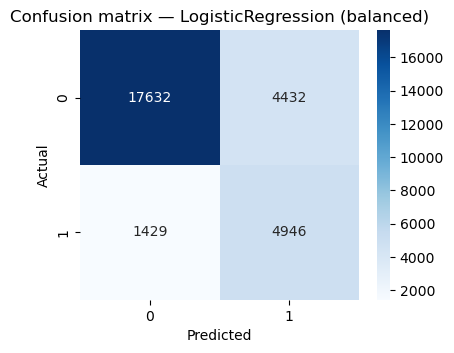

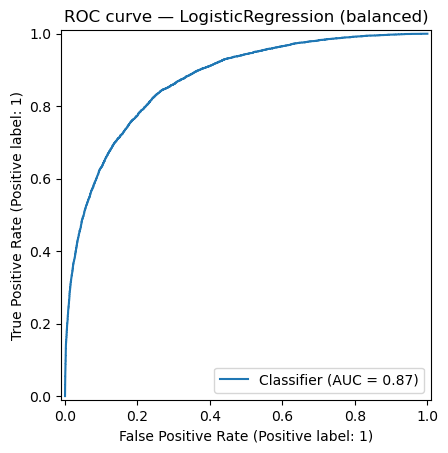

In [22]:
# Étape 8 — Logistic Regression baseline
# - On l'entraîne avec le pipeline preprocess + modèle.
# - class_weight='balanced' donne plus d'importance à la classe minoritaire (pluie).
#   But: augmenter le Recall (détecter plus de jours de pluie).

log_reg = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', LogisticRegression(max_iter=2000, class_weight='balanced', n_jobs=None)),
])

%time log_reg.fit(X_train, y_train)
_ = evaluate_binary_classifier(log_reg, X_test, y_test, model_name='LogisticRegression (balanced)')


## 9) Classification (Arbres) — Random Forest

Pourquoi ce modèle :

- capte des relations non linéaires

- souvent performant sur des données tabulaires

Note : sur certaines machines, une forêt trop grande peut être lente.
Ici on choisit des paramètres *raisonnables* pour garder un temps d’exécution acceptable.

### Équivalent Orange

- Learner **Random Forest** (régler `Number of trees`, `Max depth`, etc.)

- **Test & Score** pour Recall/F1/AUC

- **Tree Viewer** / importance (selon widgets) pour interpréter

CPU times: total: 11min 18s
Wall time: 1min 39s
== RandomForest (balanced_subsample) ==
 accuracy: 0.8357
precision: 0.6178
   recall: 0.7001
       f1: 0.6564
  roc_auc: 0.8829

Classification report:
              precision    recall  f1-score   support

          No       0.91      0.87      0.89     22064
         Yes       0.62      0.70      0.66      6375

    accuracy                           0.84     28439
   macro avg       0.76      0.79      0.77     28439
weighted avg       0.84      0.84      0.84     28439



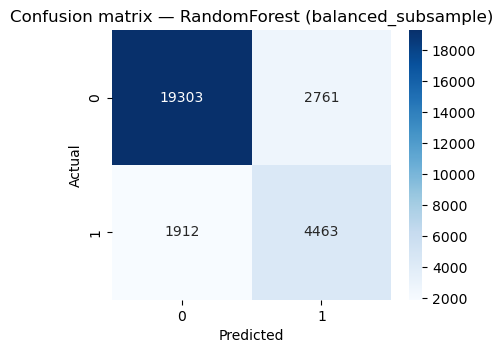

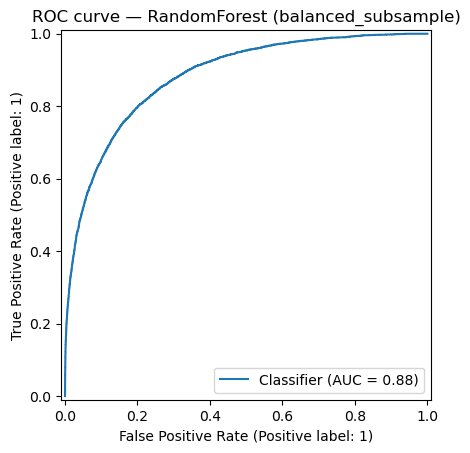

In [23]:
# Étape 9 — RandomForest
# Paramètres "rapides" par défaut:
# - n_estimators: nombre d'arbres
# - max_depth: profondeur max (contrôle la complexité)
# - min_samples_leaf: taille min d'une feuille (réduit le sur-apprentissage)

rf = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', RandomForestClassifier(
        n_estimators=200,
        max_depth=18,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        class_weight='balanced_subsample',
        n_jobs=-1,
    )),
])

%time rf.fit(X_train, y_train)
_ = evaluate_binary_classifier(rf, X_test, y_test, model_name='RandomForest (balanced_subsample)')


## 10) Classification (Arbres) — Gradient Boosting (XGBoost si dispo)

Pourquoi XGBoost :

- très performant sur données tabulaires

- gère bien des patterns non linéaires

On utilise `scale_pos_weight = n_neg / n_pos` pour aider avec le déséquilibre de classes.

### Équivalent Orange

- Si ton Orange a un learner de boosting (ex. Gradient Boosting) : l’utiliser dans **Test & Score**

- Si XGBoost n’est pas un widget disponible : ce bloc reste un *prototype Python* (via **Python Script**) mais la version finale doit rester Orange (choisir l’équivalent boosting disponible)

scale_pos_weight: 3.4605913261704964
CPU times: total: 37.4 s
Wall time: 6.46 s
== XGBoost (scale_pos_weight) ==
 accuracy: 0.8132
precision: 0.5585
   recall: 0.7953
       f1: 0.6562
  roc_auc: 0.8927

Classification report:
              precision    recall  f1-score   support

          No       0.93      0.82      0.87     22064
         Yes       0.56      0.80      0.66      6375

    accuracy                           0.81     28439
   macro avg       0.75      0.81      0.76     28439
weighted avg       0.85      0.81      0.82     28439



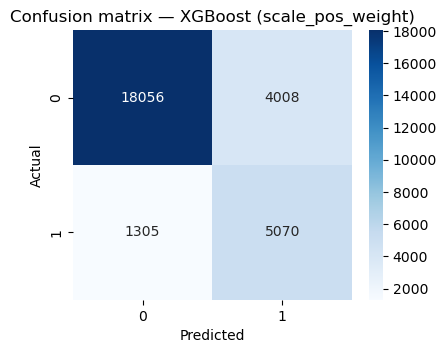

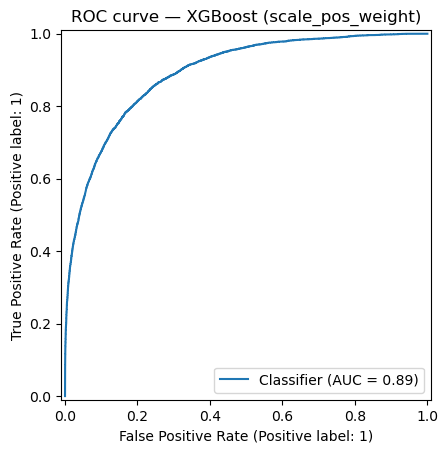

In [24]:
# Étape 10 — Entraîner XGBoost (si la lib est installée)
# XGBoost est un modèle de boosting (ensemble d'arbres) souvent très performant.
# On utilise scale_pos_weight pour gérer le déséquilibre de classes.

try:
    from xgboost import XGBClassifier

    # scale_pos_weight = negatives / positives (train)
    # Intuition: on "pèse" davantage les erreurs sur la classe minoritaire (pluie)
    n_pos = int((y_train == 1).sum())
    n_neg = int((y_train == 0).sum())
    spw = (n_neg / max(n_pos, 1))

    xgb = Pipeline(steps=[
        ('preprocess', preprocess),
        ('model', XGBClassifier(
            n_estimators=600,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.9,
            colsample_bytree=0.9,
            reg_lambda=1.0,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            eval_metric='logloss',
            scale_pos_weight=spw,
        )),
    ])

    print('scale_pos_weight:', spw)
    %time xgb.fit(X_train, y_train)
    _ = evaluate_binary_classifier(xgb, X_test, y_test, model_name='XGBoost (scale_pos_weight)')
except Exception as e:
    print("XGBoost non disponible ou erreur d'import:", repr(e))


## 11) Optimisation des hyperparamètres — profondeur (`max_depth`)

> Objectif de la consigne : **optimiser la profondeur** de certains modèles (ex. Random Forest, XGBoost) et comparer les scores.

Bonne pratique : l’optimisation se fait **sur le train** (via validation croisée) ; on garde le **test** pour l’évaluation finale.

### Équivalent Orange

- **Optimize Parameters** (si disponible) connecté à un learner (**Random Forest** / **Gradient Boosting**).
- Sinon : régler manuellement `Max depth` dans les learners, puis comparer dans **Test & Score**.
- Même idée que dans Python : optimiser avec **CV sur train**, puis évaluer **une seule fois** sur un jeu de test (hold-out).
- Si un widget manque (ou si tu veux reproduire exactement le GridSearch) : utiliser **Python Script** (comme le `GridSearchCV` ci-dessous).

CPU times: total: 4min 17s
Wall time: 13min 41s
[RF] Best params: {'model__max_depth': 10}


,params,mean_test_recall,mean_test_f1,mean_test_roc_auc,rank_test_recall
1,{'model__max_depth': 10},0.744726,0.620134,0.862158,1
0,{'model__max_depth': 6},0.738687,0.594985,0.845540,2
2,{'model__max_depth': 14},0.719473,0.639388,0.872476,3
3,{'model__max_depth': 18},0.679398,0.649270,0.877824,4
4,{'model__max_depth': None},0.590620,0.641381,0.883314,5


CPU times: total: 41.1 s
Wall time: 1min 17s
[XGB] Best params: {'model__max_depth': 4}


,params,mean_test_recall,mean_test_f1,mean_test_roc_auc,rank_test_recall
2,{'model__max_depth': 4},0.784958,0.648257,0.886290,1
1,{'model__max_depth': 3},0.783115,0.640529,0.880810,2
3,{'model__max_depth': 5},0.780174,0.654170,0.889764,3
0,{'model__max_depth': 2},0.776998,0.629918,0.873555,4
4,{'model__max_depth': 6},0.773116,0.661035,0.892169,5



Évaluation sur TEST (après tuning CV sur train):
== RandomForest tuned (refit=recall) ==
 accuracy: 0.7949
precision: 0.5296
   recall: 0.7608
       f1: 0.6245
  roc_auc: 0.8665

Classification report:
              precision    recall  f1-score   support

          No       0.92      0.80      0.86     22064
         Yes       0.53      0.76      0.62      6375

    accuracy                           0.79     28439
   macro avg       0.73      0.78      0.74     28439
weighted avg       0.83      0.79      0.81     28439



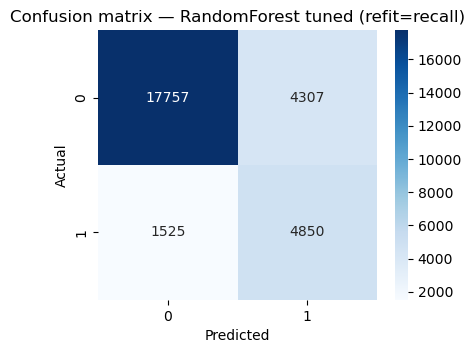

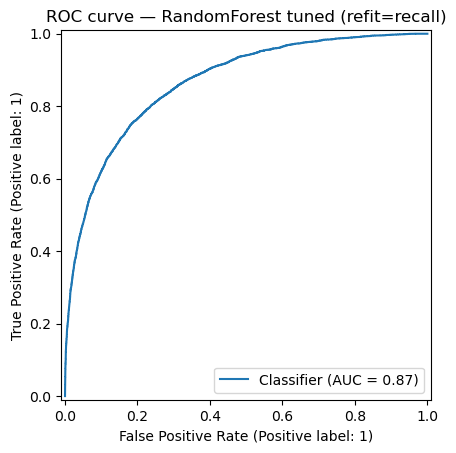

== XGBoost tuned (refit=recall) ==
 accuracy: 0.8114
precision: 0.5553
   recall: 0.7962
       f1: 0.6543
  roc_auc: 0.8909

Classification report:
              precision    recall  f1-score   support

          No       0.93      0.82      0.87     22064
         Yes       0.56      0.80      0.65      6375

    accuracy                           0.81     28439
   macro avg       0.74      0.81      0.76     28439
weighted avg       0.85      0.81      0.82     28439



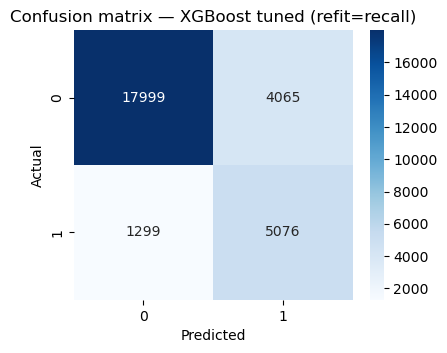

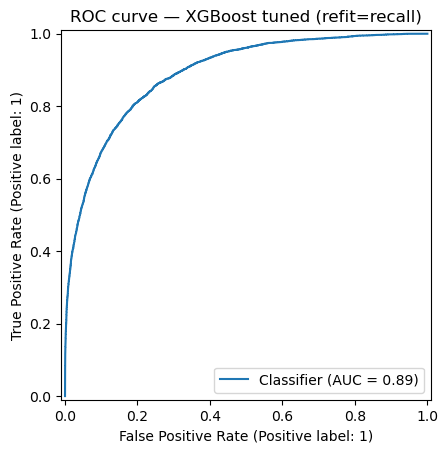

In [11]:
# Étape 11 — Optimisation de max_depth (RandomForest + XGBoost) sur TRAIN uniquement

import pandas as pd

from sklearn.model_selection import GridSearchCV, StratifiedKFold

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
}

# --- RandomForest ---
rf_base = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(
        n_estimators=250,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        class_weight="balanced_subsample",
        n_jobs=-1,
    )),
])

rf_grid = {
    "model__max_depth": [6, 10, 14, 18, None],
}

rf_search = GridSearchCV(
    estimator=rf_base,
    param_grid=rf_grid,
    scoring=scoring,
    refit="recall",
    cv=cv,
    n_jobs=-1,
    verbose=0,
)

%time rf_search.fit(X_train, y_train)

rf_results = pd.DataFrame(rf_search.cv_results_)[
    ["params", "mean_test_recall", "mean_test_f1", "mean_test_roc_auc", "rank_test_recall"]
].sort_values(["rank_test_recall", "mean_test_f1"], ascending=[True, False])

print("[RF] Best params:", rf_search.best_params_)
display(rf_results.head(10))

# --- XGBoost (si disponible) ---
xgb_search = None
xgb_results = None

try:
    from xgboost import XGBClassifier

    xgb_base = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", XGBClassifier(
            n_estimators=500,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            reg_lambda=1.0,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            eval_metric="logloss",
            scale_pos_weight=spw if "spw" in globals() else 1.0,
        )),
    ])

    xgb_grid = {
        "model__max_depth": [2, 3, 4, 5, 6],
    }

    xgb_search = GridSearchCV(
        estimator=xgb_base,
        param_grid=xgb_grid,
        scoring=scoring,
        refit="recall",
        cv=cv,
        n_jobs=-1,
        verbose=0,
    )

    %time xgb_search.fit(X_train, y_train)

    xgb_results = pd.DataFrame(xgb_search.cv_results_)[
        ["params", "mean_test_recall", "mean_test_f1", "mean_test_roc_auc", "rank_test_recall"]
    ].sort_values(["rank_test_recall", "mean_test_f1"], ascending=[True, False])

    print("[XGB] Best params:", xgb_search.best_params_)
    display(xgb_results.head(10))
except Exception as e:
    print("XGBoost non disponible pour l'optimisation:", repr(e))

# --- Évaluation finale sur TEST (une seule fois) ---
print("\nÉvaluation sur TEST (après tuning CV sur train):")
_ = evaluate_binary_classifier(rf_search.best_estimator_, X_test, y_test, model_name="RandomForest tuned (refit=recall)")

if xgb_search is not None:
    _ = evaluate_binary_classifier(xgb_search.best_estimator_, X_test, y_test, model_name="XGBoost tuned (refit=recall)")


## 12) Seuil de décision (probabilité → classe)

> Objectif : ajuster le seuil de classification pour **augmenter le Recall** (détecter plus de pluies), en contrôlant si besoin les faux positifs (FPR).

:warning: Bonne pratique : choisir le seuil sur un jeu de **validation** (pas sur le test). Ici c’est un prototype, donc on illustre la méthode sur le test.

### Équivalent Orange

- **ROC Analysis** : visualiser le compromis Recall/TPR vs FPR selon le seuil.
- **Confusion Matrix** : voir l’impact concret sur FP/FN (fausses alertes vs pluies manquées).
- Si tu dois imposer un seuil précis (ex. `0.40`) et qu’Orange ne le permet pas directement : utiliser **Python Script** pour convertir `predict_proba` → classe (Yes/No) avec le seuil choisi, puis renvoyer ces prédictions vers **Confusion Matrix**.

AUC (indépendant du seuil): 0.8909439953646433

Top seuils (triés par Recall puis F1):


,threshold,accuracy,precision,recall,f1,roc_auc
0,0.05,0.345758,0.254664,0.995765,0.405597,0.890944
1,0.10,0.453286,0.289117,0.986353,0.447163,0.890944
2,0.15,0.535532,0.322843,0.976784,0.485290,0.890944
3,0.20,0.600302,0.355321,0.961569,0.518898,0.890944
4,0.25,0.656106,0.389670,0.943216,0.551500,0.890944
5,0.30,0.698477,0.421136,0.921412,0.578064,0.890944
6,0.35,0.733289,0.451969,0.893020,0.600179,0.890944
7,0.40,0.765428,0.486940,0.865569,0.623256,0.890944



Seuil choisi: 0.4 (contraintes recall/precision)
accuracy     0.765428
precision    0.486940
recall       0.865569
f1           0.623256


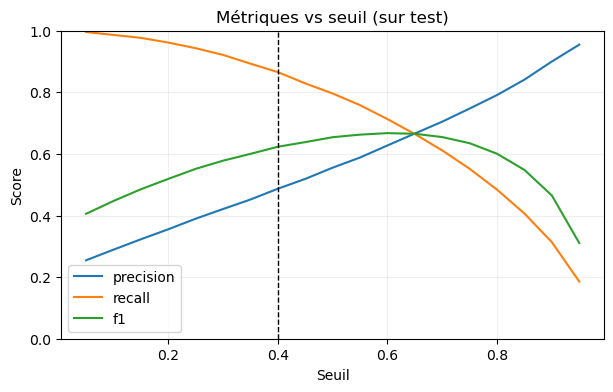

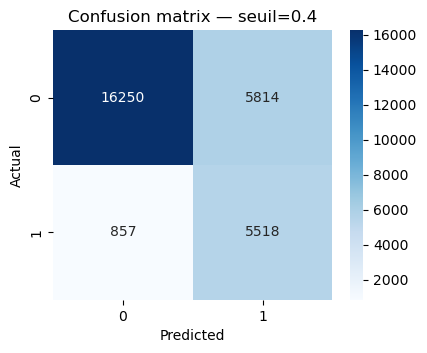

In [12]:
# 12a) Ajuster le seuil de décision (probabilité -> classe)
# Objectif: augmenter le Recall (détecter plus de jours de pluie) au prix de plus de faux positifs.
#
# IMPORTANT (bonne pratique ML):
# - Ici on choisit le seuil sur le jeu de TEST => résultat un peu "optimiste".
# - Idéalement: split Train/Validation/Test, tuner le seuil sur Validation, puis reporter le score final sur Test.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
)

# Modèle à utiliser pour le réglage du seuil
# Par défaut: on prend le meilleur XGBoost tuné s'il est disponible, sinon on retombe sur xgb/log_reg/rf.
if "xgb_search" in globals() and (xgb_search is not None) and hasattr(xgb_search, "best_estimator_"):
    model_for_threshold = xgb_search.best_estimator_
elif "xgb" in globals():
    model_for_threshold = xgb
elif "rf_search" in globals() and hasattr(rf_search, "best_estimator_"):
    model_for_threshold = rf_search.best_estimator_
else:
    model_for_threshold = log_reg

# Contraintes simples (à ajuster)
TARGET_RECALL = 0.85      # viser au moins ce recall si possible
MIN_PRECISION = 0.45      # éviter un modèle qui “crie pluie” tout le temps

# Grille de seuils
thresholds = np.round(np.linspace(0.05, 0.95, 19), 2)

# Probabilités
if not hasattr(model_for_threshold, "predict_proba"):
    raise ValueError("Le modèle choisi n'expose pas predict_proba().")

y_proba = model_for_threshold.predict_proba(X_test)[:, 1]

rows = []
for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    rows.append({
        "threshold": float(t),
        "accuracy": accuracy_score(y_test, y_pred_t),
        "precision": precision_score(y_test, y_pred_t, zero_division=0),
        "recall": recall_score(y_test, y_pred_t, zero_division=0),
        "f1": f1_score(y_test, y_pred_t, zero_division=0),
    })

df_thr = pd.DataFrame(rows)
df_thr["roc_auc"] = roc_auc_score(y_test, y_proba)

# Choix du seuil: d'abord on cherche à atteindre TARGET_RECALL et MIN_PRECISION, sinon meilleur F1
candidates = df_thr[(df_thr["recall"] >= TARGET_RECALL) & (df_thr["precision"] >= MIN_PRECISION)].copy()
if len(candidates) > 0:
    chosen = candidates.sort_values(["f1", "recall"], ascending=False).iloc[0]
    chosen_reason = "contraintes recall/precision"
else:
    chosen = df_thr.sort_values(["f1", "recall"], ascending=False).iloc[0]
    chosen_reason = "meilleur F1 (fallback)"

chosen_t = float(chosen["threshold"])

print("AUC (indépendant du seuil):", float(df_thr["roc_auc"].iloc[0]))
print("\nTop seuils (triés par Recall puis F1):")
display(df_thr.sort_values(["recall", "f1"], ascending=False).head(8))

print("\nSeuil choisi:", chosen_t, f"({chosen_reason})")
print(chosen[["accuracy", "precision", "recall", "f1"]].to_string())

# Visualisation des métriques vs seuil
plt.figure(figsize=(7, 4))
plt.plot(df_thr["threshold"], df_thr["precision"], label="precision")
plt.plot(df_thr["threshold"], df_thr["recall"], label="recall")
plt.plot(df_thr["threshold"], df_thr["f1"], label="f1")
plt.axvline(chosen_t, color="black", linestyle="--", linewidth=1)
plt.title("Métriques vs seuil (sur test)")
plt.xlabel("Seuil")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.grid(True, alpha=0.2)
plt.legend()
plt.show()

# Matrice de confusion au seuil choisi
y_pred_chosen = (y_proba >= chosen_t).astype(int)
cm = confusion_matrix(y_test, y_pred_chosen)
plt.figure(figsize=(4.5, 3.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion matrix — seuil={chosen_t}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [13]:
# 12b) Choisir un seuil sous contrainte de faux positifs (FPR)
# Idée: on veut un Recall élevé, MAIS on limite le taux de fausses alertes pluie.
# FPR = FP / (FP + TN)
#
# IMPORTANT (bonne pratique ML): même remarque que pour 12a.
# Idéalement, on fixe le seuil sur un jeu de validation, puis on évalue 1 fois sur le test.

import numpy as np
import pandas as pd

from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score

# Choisir le meilleur modèle (même logique que 12a)
if "xgb_search" in globals() and (xgb_search is not None) and hasattr(xgb_search, "best_estimator_"):
    model_for_threshold = xgb_search.best_estimator_
elif "xgb" in globals():
    model_for_threshold = xgb
elif "rf_search" in globals() and hasattr(rf_search, "best_estimator_"):
    model_for_threshold = rf_search.best_estimator_
else:
    model_for_threshold = log_reg

MAX_FPR = 0.25  # ex: accepter au plus 25% de faux positifs sur la classe "No"

thresholds = np.round(np.linspace(0.05, 0.95, 19), 2)
y_proba = model_for_threshold.predict_proba(X_test)[:, 1]

rows = []
for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
    rows.append({
        "threshold": float(t),
        "fpr": float(fpr),
        "accuracy": accuracy_score(y_test, y_pred_t),
        "precision": precision_score(y_test, y_pred_t, zero_division=0),
        "recall": recall_score(y_test, y_pred_t, zero_division=0),
        "f1": f1_score(y_test, y_pred_t, zero_division=0),
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
    })

df_fpr = pd.DataFrame(rows)

# Choix: parmi les seuils qui respectent la contrainte FPR, maximiser Recall puis F1
candidates = df_fpr[df_fpr["fpr"] <= MAX_FPR].copy()
if len(candidates) == 0:
    print("Aucun seuil ne respecte MAX_FPR=", MAX_FPR)
    display(df_fpr.sort_values(["fpr", "recall"], ascending=[True, False]).head(10))
else:
    best = candidates.sort_values(["recall", "f1"], ascending=False).iloc[0]
    print("Seuil sous contrainte FPR choisi:", float(best["threshold"]))
    print(best[["fpr", "precision", "recall", "f1", "accuracy"]].to_string())
    print("Confusion: TN={tn}, FP={fp}, FN={fn}, TP={tp}".format(**best.to_dict()))

    print("\nTop 8 candidats (FPR <= MAX_FPR), triés par Recall puis F1:")
    display(candidates.sort_values(["recall", "f1"], ascending=False).head(8))


Seuil sous contrainte FPR choisi: 0.45
fpr          0.222036
precision    0.518951
recall       0.829020
f1           0.638324
accuracy     0.789409
Confusion: TN=17165.0, FP=4899.0, FN=1090.0, TP=5285.0

Top 8 candidats (FPR <= MAX_FPR), triés par Recall puis F1:


,threshold,fpr,accuracy,precision,recall,f1,tn,fp,fn,tp
8,0.45,0.222036,0.789409,0.518951,0.829020,0.638324,17165,4899,1090,5285
9,0.50,0.184237,0.811386,0.555300,0.796235,0.654292,17999,4065,1299,5076
10,0.55,0.153281,0.826893,0.588364,0.758275,0.662600,18682,3382,1541,4834
11,0.60,0.122281,0.840782,0.627502,0.712941,0.667499,19366,2698,1830,4545
12,0.65,0.096175,0.850171,0.666247,0.664471,0.665358,19942,2122,2139,4236
13,0.70,0.074012,0.855445,0.704702,0.611294,0.654683,20431,1633,2478,3897
14,0.75,0.053889,0.857695,0.747344,0.551686,0.634780,20875,1189,2858,3517
15,0.80,0.036893,0.855691,0.791229,0.483922,0.600545,21250,814,3290,3085


## 13) Interprétation — variables physiques déterminantes

> Objectif : identifier les variables qui contribuent le plus aux prédictions (et les relier au phénomène physique).

:bulb: Sur ce dataset, on observe souvent que l’**humidité** (ex. `Humidity3pm`) et la **pression** (ex. `Pressure3pm`) sont très informatives pour la pluie du lendemain. Le point n’est pas seulement d’avoir un score, mais de pouvoir **argumenter**.

### Équivalent Orange

- **Rank** : classer les variables (selon une mesure de pertinence) et discuter les variables “physiques”.
- **Feature Statistics** : vérifier distribution / valeurs manquantes / ordres de grandeur.
- Modèles arbres : selon les widgets/learners, consulter l’**importance** ou un **Tree Viewer**.
- Si tu veux reproduire exactement l’extraction des importances/coefficients : **Python Script**.

In [16]:
# Étape 13 — Interprétation: importances / coefficients

import numpy as np
import pandas as pd


def _get_feature_names_from_preprocess(preprocess):
    try:
        return preprocess.get_feature_names_out()
    except Exception:
        # Fallback très simple si get_feature_names_out n'est pas dispo
        # (les noms seront moins détaillés pour les one-hot)
        return np.array(list(numeric_features) + list(categorical_features), dtype=object)


def _top_features_from_pipeline(pipeline, top_n=20, name="model"):
    preprocess_step = pipeline.named_steps.get("preprocess")
    model_step = pipeline.named_steps.get("model")

    if preprocess_step is None or model_step is None:
        print(f"[{name}] Pipeline inattendu (pas de preprocess/model).")
        return

    feat_names = _get_feature_names_from_preprocess(preprocess_step)

    if hasattr(model_step, "feature_importances_"):
        importances = np.asarray(model_step.feature_importances_)
        df_imp = pd.DataFrame({
            "feature": feat_names,
            "importance": importances,
            "abs_importance": np.abs(importances),
        }).sort_values("abs_importance", ascending=False)
        print(f"\nTop {top_n} importances — {name}")
        display(df_imp.head(top_n))
        return df_imp

    if hasattr(model_step, "coef_"):
        coefs = np.asarray(model_step.coef_).ravel()
        df_coef = pd.DataFrame({
            "feature": feat_names,
            "coef": coefs,
            "abs_coef": np.abs(coefs),
        }).sort_values("abs_coef", ascending=False)
        print(f"\nTop {top_n} |coefficients| — {name}")
        display(df_coef.head(top_n))
        return df_coef

    print(f"[{name}] Pas d'attribut feature_importances_ ni coef_.")


# Choisir des modèles à interpréter (si les cellules précédentes ont été exécutées)
models_to_explain = []

# Tunés (si disponibles)
if "rf_search" in globals() and hasattr(rf_search, "best_estimator_"):
    models_to_explain.append((rf_search.best_estimator_, "RandomForest tuned"))
elif "rf" in globals():
    models_to_explain.append((rf, "RandomForest"))

if "xgb_search" in globals() and (xgb_search is not None) and hasattr(xgb_search, "best_estimator_"):
    models_to_explain.append((xgb_search.best_estimator_, "XGBoost tuned"))
elif "xgb" in globals():
    models_to_explain.append((xgb, "XGBoost"))

if "log_reg" in globals():
    models_to_explain.append((log_reg, "LogisticRegression"))

for mdl, mdl_name in models_to_explain:
    _top_features_from_pipeline(mdl, top_n=25, name=mdl_name)



Top 25 importances — RandomForest tuned


,feature,importance,abs_importance
9,num__Humidity3pm,0.237799,0.237799
4,num__Sunshine,0.091889,0.091889
2,num__Rainfall,0.089690,0.089690
13,num__Cloud3pm,0.067740,0.067740
113,cat__RainToday_No,0.057036,0.057036
8,num__Humidity9am,0.055014,0.055014
11,num__Pressure3pm,0.053898,0.053898
5,num__WindGustSpeed,0.053639,0.053639
114,cat__RainToday_Yes,0.053193,0.053193
10,num__Pressure9am,0.048688,0.048688



Top 25 importances — XGBoost tuned


,feature,importance,abs_importance
9,num__Humidity3pm,0.119100,0.119100
2,num__Rainfall,0.058728,0.058728
4,num__Sunshine,0.044349,0.044349
113,cat__RainToday_No,0.043011,0.043011
13,num__Cloud3pm,0.035670,0.035670
5,num__WindGustSpeed,0.030622,0.030622
11,num__Pressure3pm,0.025188,0.025188
103,cat__WindDir3pm_NNW,0.015487,0.015487
100,cat__WindDir3pm_N,0.014625,0.014625
86,cat__WindDir9am_NNE,0.013291,0.013291


## 14) Bonus — Calibration des probabilités

> Objectif : vérifier si les probabilités prédites sont *bien calibrées* (ex. un score 0.7 correspond-il vraiment à ~70% de pluie?).

:information_source: La calibration est différente des métriques de classification au seuil 0.5. Un modèle peut être performant mais mal calibré.

### Équivalent Orange

- **Calibration Plot** (si disponible) connecté aux sorties de **Test & Score** / learners.
- Sinon : **Python Script** pour tracer la courbe de calibration (comme dans ce notebook).

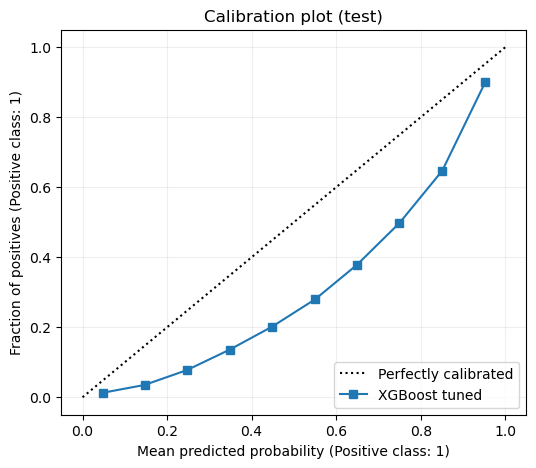

In [14]:
# Étape 14 — Courbe de calibration

from sklearn.calibration import CalibrationDisplay

plt.figure(figsize=(6, 5))
ax = plt.gca()

# Choisir 1) un modèle "probabiliste" simple (LR) et 2) le meilleur modèle (si dispo)
calib_models = []
if "log_reg" in globals():
    calib_models.append((log_reg, "LogisticRegression"))

best_model = None
best_name = None
if "xgb_search" in globals() and (xgb_search is not None) and hasattr(xgb_search, "best_estimator_"):
    best_model = xgb_search.best_estimator_
    best_name = "XGBoost tuned"
elif "rf_search" in globals() and hasattr(rf_search, "best_estimator_"):
    best_model = rf_search.best_estimator_
    best_name = "RandomForest tuned"
elif "xgb" in globals():
    best_model = xgb
    best_name = "XGBoost"
elif "rf" in globals():
    best_model = rf
    best_name = "RandomForest"

if best_model is not None:
    calib_models.append((best_model, best_name))

if len(calib_models) == 0:
    print("Aucun modèle disponible pour la calibration (exécuter les étapes modèles).")
else:
    for mdl, nm in calib_models:
        if not hasattr(mdl, "predict_proba"):
            print(f"{nm}: pas de predict_proba(), calibration non tracée")
            continue
        y_proba_m = mdl.predict_proba(X_test)[:, 1]
        CalibrationDisplay.from_predictions(
            y_test,
            y_proba_m,
            n_bins=10,
            name=nm,
            ax=ax,
        )

    plt.title("Calibration plot (test)")
    plt.grid(True, alpha=0.2)
    plt.show()


## 15) Bonus — Réseau de neurones (MLP)

> Objectif : tester un **Neural Network** simple sur ce problème tabulaire, et comparer Recall/F1/AUC.

:information_source: Les MLP peuvent être sensibles au prétraitement et au réglage d’hyperparamètres; on garde un paramétrage modéré pour un temps de calcul raisonnable.

### Équivalent Orange

- Learner **Neural Network** + **Test & Score**.
- Si tu as besoin de réglages avancés (pondération de classes / `sample_weight`, architecture, etc.) : **Python Script**.

CPU times: total: 1min 7s
Wall time: 17.7 s
== Neural Network (MLP) ==
 accuracy: 0.8094
precision: 0.5506
   recall: 0.8147
       f1: 0.6571
  roc_auc: 0.8959

Classification report:
              precision    recall  f1-score   support

          No       0.94      0.81      0.87     22064
         Yes       0.55      0.81      0.66      6375

    accuracy                           0.81     28439
   macro avg       0.74      0.81      0.76     28439
weighted avg       0.85      0.81      0.82     28439



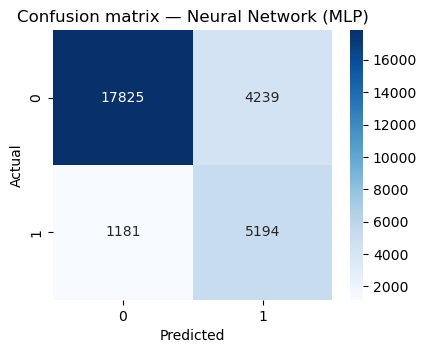

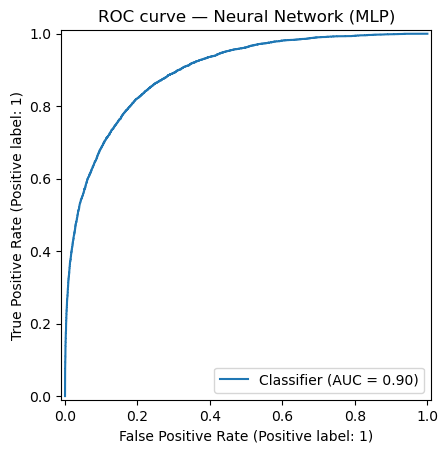

In [15]:
# Étape 15 — MLPClassifier (réseau de neurones)

from sklearn.neural_network import MLPClassifier
from sklearn.utils.class_weight import compute_sample_weight

# Pondération des exemples pour compenser le déséquilibre (équivalent à class_weight)
sample_weight = compute_sample_weight(class_weight="balanced", y=y_train)

mlp = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        alpha=1e-4,
        learning_rate_init=1e-3,
        max_iter=300,
        early_stopping=True,
        random_state=RANDOM_STATE,
    )),
])

%time mlp.fit(X_train, y_train, model__sample_weight=sample_weight)
_ = evaluate_binary_classifier(mlp, X_test, y_test, model_name="Neural Network (MLP)")


## Workflow général Orange (à reproduire en `.ows`)

L’objectif ici est de refaire **le même pipeline** que dans Python, mais **uniquement avec des widgets Orange** (et **Python Script** seulement si un widget manque).

### 1) Chaîne de widgets (version “standard”)

1. **File**
   - Charger `data/weatherAUS.csv`.
2. **Select Columns**
   - Target (classe): `RainTomorrow`.
   - Features: toutes les autres colonnes utiles.
   - *Optionnel*: retirer les colonnes inutiles (identifiants, colonnes trop vides si besoin).
3. **Impute**
   - Numériques: remplacer les valeurs manquantes (moyenne ou médiane).
   - Catégorielles: remplacer les manquants (valeur la plus fréquente).
4. **Continuize** (ou **One Hot Encoding / Continuize** selon version)
   - Convertir les variables catégorielles en variables numériques (one-hot).
5. **Normalize**
   - Standardisation (z-score) recommandée pour Logistic Regression / Neural Network.
   - (Pour Random Forest / Boosting, c’est moins critique, mais garder la même chaîne simplifie.)
6. **PCA** (si demandé dans la consigne / bonus)
   - Garder un nombre de composantes expliquant ~95% de variance (ou un nombre fixe).
   - Si PCA est utilisée, elle doit être placée **après** l’encodage + normalisation.
7. **Data Sampler** (ou **Split Data** / **Data Sampler** selon version)
   - Split train/test (ex: 80/20).
   - Stratification: si disponible, activer pour conserver le ratio pluie/non-pluie.
8. **Learner(s)**
   - **Logistic Regression** (baseline)
   - **Random Forest**
   - **Neural Network** (MLP)
   - **(Boosting)**: si Orange propose un learner type Gradient Boosting / XGBoost (selon installation). Sinon, passer par Python Script.
9. **Test & Score**
   - Évaluer tous les learners sur le split (ou via CV si demandé).
   - Métriques à afficher: Accuracy, Precision, Recall, F1, AUC.
10. **Confusion Matrix**
    - Lire FP/FN et vérifier si le Recall correspond à l’objectif (détecter la pluie).
11. **ROC Analysis** + **Calibration Plot** (bonus)
    - ROC: comparer AUC + comprendre l’effet du seuil.
    - Calibration: vérifier si les probabilités sont bien calibrées.

### 2) Ajuster le seuil dans Orange (équivalent du “threshold tuning”)

Orange évalue souvent avec un seuil implicite (souvent 0.5). Pour **augmenter le Recall**, il faut **abaisser le seuil**.

- Si votre version d’Orange propose un widget/option de **threshold**: l’utiliser pour choisir un seuil (ex: 0.40–0.45 selon nos résultats Python).
- Sinon (le plus simple): utiliser **Python Script** pour:
  - récupérer les probabilités (`predict_proba`),
  - balayer des seuils,
  - choisir celui qui maximise le Recall (ou respecte une contrainte de FPR),
  - renvoyer les prédictions “Yes/No” vers Confusion Matrix.

### 3) Où utiliser “Python Script” (fallback)

Utiliser **Python Script** uniquement si nécessaire, par exemple pour:
- XGBoost (si pas de learner équivalent installé dans Orange),
- la création de variables (ex: sin/cos pour directions de vent) si vous ne pouvez pas le faire via un widget,
- l’optimisation du **seuil** si Orange ne donne pas de contrôle direct.

## Diagramme du workflow Orange

```mermaid
flowchart LR
  A[File\nweatherAUS.csv] --> B[Select Columns\nTarget: RainTomorrow]
  B --> C[Impute\nmissing values]
  C --> D[Continuize / One-hot\ncategorical -> numeric]
  D --> E[Normalize\nZ-score]
  E --> F[PCA\n(optional)]
  F --> G[Data Sampler / Split\nTrain/Test]

  G --> H1[Logistic Regression\nLearner]
  G --> H2[Random Forest\nLearner]
  G --> H3[Neural Network\nLearner]
  G --> H4[Boosting Learner\n(or Python Script)]

  H1 --> I[Test & Score]
  H2 --> I
  H3 --> I
  H4 --> I

  I --> J[Confusion Matrix]
  I --> K[ROC Analysis]
  I --> L[Calibration Plot\n(optional)]

  %% Optional threshold tuning path
  I -. optional .-> P[Python Script\nThreshold tuning]
  P -.-> J
```

### Check-list rapide (validation)

- Même variable cible (`RainTomorrow`) et même split (train/test ou CV).
- Imputation + encodage catégoriel identiques (pas de fuite de données).
- Comparer Recall/F1/AUC entre learners.
- Si objectif Recall: vérifier impact du seuil (ROC/CM).

### Check-list démo Orange (ultra-courte, 2–3 minutes)

- **File** → charger `data/weatherAUS.csv`.
- **Select Columns** → Target = `RainTomorrow`.
- **Impute** → gérer les NaN (numériques + catégorielles).
- **Continuize** → one-hot des catégorielles.
- **Normalize** → z-score.
- **Random Forest** + **Logistic Regression** (2 learners suffisent en démo).
- **Test & Score** → afficher Recall/F1/AUC.
- **Confusion Matrix** → vérifier FN (pluies manquées) vs FP (fausses alertes).
- **ROC Analysis** → expliquer “bouger le seuil = bouger le compromis”.